# Adaptive block-specific selection — ONE-SIDED (rose MORE than ecotype), site 4

We test, per haploblock, whether its temporal allele-frequency change is **larger than its
founder/ecotype background predicts** (`resid > 0`). This is the *adaptive* direction: an allele
whose carriers changed beyond what hitchhiking on their winning ecotypes explains.

## The model

Identical fit to the sampling-variance-weighted LD mixed model; only the **test is one-sided**.

**Response.** Per block $b$, per plot $j$: OLS slope $\beta_{b,j}$ of $\operatorname{logit}(f)$ over
generations $t=0..3$; $s_b=\frac1n\sum_j\beta_{b,j}$. Each timepoint carries its **honest binomial
sampling variance with the FLOWER census** as $N^{\text{eff}}=2\,\text{flowers}$ (kMate accuracy is
high, so read depth is not the limit):
$$\operatorname{Var}(\operatorname{logit} f_t)=\frac{1}{N^{\text{eff}}_t\,f_t(1-f_t)} \;\Rightarrow\;
V^{\text{samp}}_b=\tfrac1n\overline{\sum_t \tfrac{(t-1.5)^2}{25}\operatorname{Var}(\operatorname{logit} f_t)},\quad
\mathrm{SE}^2_b=\max(V^{\text{drift}}_b,\,V^{\text{samp}}_b).$$
This blows up near the frequency boundary, so rare/near-fixed haplotypes self-down-weight (the
flat precision was the source of the inflated tail).

**Kinship / linkage.** $\mathbf g\sim\mathcal N(0,\sigma_g^2\mathbf C_{LD})$, $\mathbf C_{LD}$ the
founder-relationship matrix; $\mathbf g$ absorbs the clade-wide hitchhiking background. Fit by REML.

**One-sided adaptive test.**
$$r_b=s_b-\hat g_b,\qquad z_b=\frac{r_b}{\sqrt{\sigma_e^2+\mathrm{SE}_b^2}},\qquad
p_b=P(Z\ge z_b)=\Phi(-z_b).$$
We test the **upper tail only**: $r_b>0$ = the allele changed *more* than its relatedness predicts
= **adaptive / convergent**. (A two-sided test was dominated by `resid<0` BLUP-over-prediction
artifacts — risers that rose *less* than predicted — which is the opposite of what we want.)

**Caveat.** The underlying fit is median-calibrated ($\lambda_{GC}\approx0.97$); a one-sided
WF-drift-projection null is the proper tail calibration (see the other notebook's drift-null) and
should confirm any survivor. Treat these as ranked adaptive candidates.

## Load the precomputed one-sided adaptive solution

In [1]:
import os, json
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
os.chdir("/global/scratch/users/tbellg/kmate")
H="results/grenenet_gea/hapfreq"; SITE=4; CHROMS=["Chr1","Chr2","Chr3","Chr4","Chr5"]

In [2]:
d=pd.read_csv(f"{H}/site{SITE}_block_ld_lmm_oneside.csv")   # one-sided p (resid>0)
meta=json.load(open(f"{H}/site{SITE}_block_ld_lmm_oneside_meta.json"))
h2=float(meta["h2"]); lam=float(meta["lambda_gc"]); m=len(d); bonf=0.05/m
print(f"site {SITE}: {m:,} haploblocks | one-sided ADAPTIVE test (resid>0 = rose MORE than ecotype)")
print(f"  REML h2(linkage)={h2:.2f}  (model two-sided-equiv λ_GC={lam:.2f})")
print(f"  adaptive hits: Bonferroni {int((d.p<bonf).sum())} | FDR q<0.05 {int((d.q<0.05).sum())} | best q={d.q.min():.3f}")

site 4: 26,243 haploblocks | one-sided ADAPTIVE test (resid>0 = rose MORE than ecotype)
  REML h2(linkage)=0.83  (model two-sided-equiv λ_GC=0.97)
  adaptive hits: Bonferroni 0 | FDR q<0.05 8 | best q=0.027


## Manhattan — adaptive overperformers (rose MORE than ecotype)

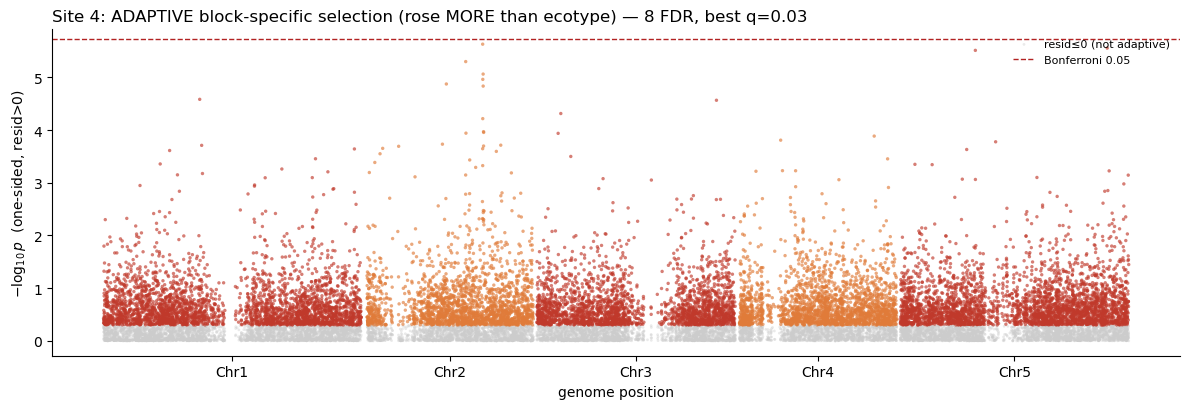

In [3]:
g2=d.copy(); g2["mid"]=(g2.unit_start+g2.unit_end)/2
g2=g2.sort_values(["chrom","unit_start"]).reset_index(drop=True)
off,centers,x=0.0,[],np.zeros(len(g2))
for ch in CHROMS:
    mk=(g2.chrom==ch).to_numpy()
    if not mk.any(): continue
    x[mk]=g2.mid[mk]+off; centers.append(off+g2.mid[mk].max()/2); off+=g2.mid[mk].max()*1.02
g2["x"]=x; nlp=-np.log10(np.clip(g2.p,1e-300,1)); adp=g2.resid.values>0
fig,ax=plt.subplots(figsize=(12,4.2))
ax.scatter(g2.x[~adp],nlp[~adp],s=4,c="#cccccc",alpha=.4,edgecolors="none",label="resid≤0 (not adaptive)")
for i,ch in enumerate(CHROMS):
    mk=((g2.chrom==ch)&adp).to_numpy()
    ax.scatter(g2.x[mk],nlp[mk],s=6,c=["#c0392b","#e07b39"][i%2],alpha=.65,edgecolors="none")
ax.axhline(-np.log10(bonf),color="firebrick",lw=1,ls="--",label="Bonferroni 0.05")
ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
ax.set_ylabel(r"$-\log_{10}p$  (one-sided, resid>0)"); ax.set_xlabel("genome position")
ax.set_title(f"Site {SITE}: ADAPTIVE block-specific selection (rose MORE than ecotype) — "
             f"{int((d.q<0.05).sum())} FDR, best q={d.q.min():.2f}",loc="left")
ax.legend(frameon=False,fontsize=8,loc="upper right"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## QQ — one-sided adaptive p-values

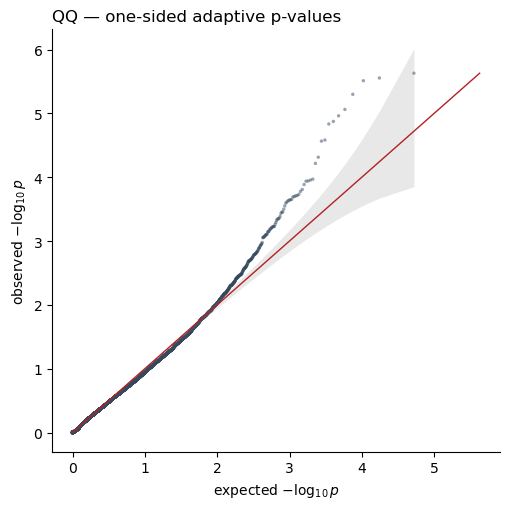

In [4]:
from scipy.stats import beta as _beta
pv=np.sort(d.p.values); exp=-np.log10((np.arange(1,m+1)-0.5)/m); obs=-np.log10(np.clip(pv,1e-300,1))
fig,ax=plt.subplots(figsize=(5.2,5.2))
ax.scatter(exp,obs,s=6,c="#34495e",alpha=.5,edgecolors="none")
lim=max(exp.max(),obs.max()); ax.plot([0,lim],[0,lim],color="firebrick",lw=1)
_i=np.arange(1,m+1); _lo=_beta.ppf(0.025,_i,m-_i+1); _hi=_beta.ppf(0.975,_i,m-_i+1)
ax.fill_between(exp,-np.log10(np.clip(_hi,1e-300,1)),-np.log10(np.clip(_lo,1e-300,1)),color="grey",alpha=.18,lw=0)
ax.set_xlabel(r"expected $-\log_{10}p$"); ax.set_ylabel(r"observed $-\log_{10}p$")
ax.set_title("QQ — one-sided adaptive p-values",loc="left"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Adaptive hits by minor-allele frequency

In [5]:
d["maf"]=np.minimum(d.panel_freq,1-d.panel_freq)
def lam(p): c=stats.chi2.isf(np.clip(2*np.minimum(p,1-p),1e-300,1),1); return np.median(c)/stats.chi2.ppf(0.5,1)
pd.DataFrame([{"MAF":f"[{lo:.2f},{hi:.2f}]","n":len(d[d.maf.between(lo,hi)]),
               "FDR_adaptive_hits":int((d[d.maf.between(lo,hi)].q<0.05).sum()),
               "best_q":round(d[d.maf.between(lo,hi)].q.min(),3)}
              for lo,hi in [(0.05,0.10),(0.10,0.20),(0.20,0.30),(0.30,0.40),(0.40,0.50)]])

,MAF,n,FDR_adaptive_hits,best_q
0,"[0.05,0.10]",7312,5,0.027
1,"[0.10,0.20]",9393,3,0.046
2,"[0.20,0.30]",5237,0,0.133
3,"[0.30,0.40]",3013,0,0.190
4,"[0.40,0.50]",1288,0,0.222


## Top adaptive overperformers

In [6]:
d.sort_values("p").head(15)[["chrom","unit_start","unit_end","panel_freq","s","linked_bg","resid","z","p","q"]]

,chrom,unit_start,unit_end,panel_freq,s,linked_bg,resid,z,p,q
0,Chr2,13713039,13716149,0.09957,0.785529,0.252421,0.575527,4.577692,0.000002,0.026954
1,Chr5,24431218,24432490,0.94805,-0.948500,-1.469989,0.563908,4.541792,0.000003,0.026954
2,Chr5,8882661,8884434,0.94805,-0.876506,-1.419395,0.585309,4.520733,0.000003,0.026954
3,Chr2,11710710,11717696,0.07792,0.870632,0.337907,0.575144,4.415924,0.000005,0.032994
4,Chr2,13767308,13770264,0.10823,0.775515,0.285464,0.532471,4.296347,0.000009,0.045567
5,Chr2,13725657,13732568,0.10823,0.606477,0.120971,0.527925,4.244822,0.000011,0.047842
6,Chr2,9430586,9434041,0.94805,-0.687260,-1.181679,0.536839,4.199407,0.000013,0.048128
7,Chr2,13770439,13775598,0.14719,0.546366,0.103648,0.485137,4.178507,0.000015,0.048128
8,Chr1,11357333,11360467,0.94805,-0.800486,-1.262563,0.504496,4.044954,0.000026,0.071491
9,Chr3,21198212,21215791,0.07792,0.485666,0.037585,0.490502,4.035509,0.000027,0.071491


## Genes in the adaptive blocks

In [7]:
# --- genes in the adaptive (q<0.05) blocks, annotated from Ensembl Plants ---
gt=pd.read_csv(f"{H}/site{SITE}_ldlmm_oneside_genes.csv")
gt["region"]=gt.chrom+":"+gt.start.astype(str)+"-"+gt.end.astype(str)
disp=gt[["bonferroni","region","panel_freq","resid","q","n_genes","symbols","gene_descriptions"]].rename(
    columns={"bonferroni":"Bonf","gene_descriptions":"genes (symbol: Ensembl description)"})
print(f"{len(gt)} adaptive FDR blocks ; {int((gt.n_genes>0).sum())} overlap >=1 gene")
print("notable: Chr2:13.7Mb cluster = BAM6 (beta-amylase), KAO2 (gibberellin biosynth), AT2G32310-32340;")
print("         + EPR1 (circadian MYB), TPPE (trehalose/sugar-stress).")
disp

8 adaptive FDR blocks ; 7 overlap >=1 gene
notable: Chr2:13.7Mb cluster = BAM6 (beta-amylase), KAO2 (gibberellin biosynth), AT2G32310-32340;
         + EPR1 (circadian MYB), TPPE (trehalose/sugar-stress).


,Bonf,region,panel_freq,resid,q,n_genes,symbols,genes (symbol: Ensembl description)
0,NaN,Chr2:13713039-13716149,0.09957,0.575527,0.026954,2,AT2G32280;BAM6,"AT2G32280: GPI inositol-deacylase C, putative ..."
1,NaN,Chr5:24431218-24432490,0.94805,0.563908,0.026954,1,AT5G60750,AT5G60750: CAAX amino terminal protease family...
2,NaN,Chr5:8882661-8884434,0.94805,0.585309,0.026954,1,AT5G25510,AT5G25510: Protein phosphatase 2A regulatory B...
3,NaN,Chr2:11710710-11717696,0.07792,0.575144,0.032994,2,EPR1;AT2G27385,EPR1: extensin proline-rich 1; AT2G27385: Poll...
4,NaN,Chr2:13767308-13770264,0.10823,0.532471,0.045567,0,NaN,NaN
5,NaN,Chr2:13725657-13732568,0.10823,0.527925,0.047842,4,AT2G32310;AT2G32315;AT2G32320;AT2G32340,AT2G32310: CCT motif family protein; AT2G32315...
6,NaN,Chr2:9430586-9434041,0.94805,0.536839,0.048128,4,AT2G07525;AT2G07535;AT2G07545;TPPE,AT2G07525: ncRNA; AT2G07535: ncRNA; AT2G07545:...
7,NaN,Chr2:13770439-13775598,0.14719,0.485137,0.048128,2,AT2G32430;KAO2,AT2G32430: Galactosyltransferase family protei...
